# Data Center Health AI: Model Benchmarking, Evaluation & Champion Selection
**Author:** Chaitanya Kiran  
**Domain:** High-Density Telemetry Anomaly Detection (AIOps)  
**Evaluation Standard:** Point-Adjusted F1 (PA-F1), Area Under Precision-Recall Curve (PR-AUC), and Sub-15ms Latency  
**Candidate Models:** Isolation Forest, PCA Reconstruction, Local Outlier Factor, One-Class SVM, LSTM Autoencoder (PyTorch)

## 1. Setup & Load Benchmark Artifacts

In [1]:
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Load benchmark results table
csv_path = project_root / 'artifacts' / 'reports' / 'model_comparison_table.csv'
df_results = pd.read_csv(csv_path)
display(df_results[['model_name', 'pa_f1_score', 'f1_score', 'precision', 'recall', 'pr_auc', 'roc_auc', 'latency_ms', 'fit_time_sec']])

,model_name,pa_f1_score,f1_score,precision,recall,pr_auc,roc_auc,latency_ms,fit_time_sec
0,IsolationForest,0.4585,0.4562,0.2961,0.9937,0.3764,0.9153,0.016,0.00
1,PCADetector,0.3380,0.0360,0.6250,0.0186,0.6113,0.9208,0.003,0.00
2,LocalOutlierFactor,0.3370,0.0678,0.7059,0.0356,0.6335,0.9116,0.064,0.00
3,OneClassSVM,0.4551,0.4458,0.2891,0.9736,0.7068,0.9617,0.176,0.00
4,RobustCovariance,0.6412,0.5690,0.4295,0.8426,0.5904,0.9477,0.001,0.00
5,LSTMAutoencoder,0.3382,0.0247,0.5484,0.0126,0.6451,0.9492,0.265,144.69


## 2. Benchmark Visualizations: F1, Precision vs Recall, PR-AUC & Latency

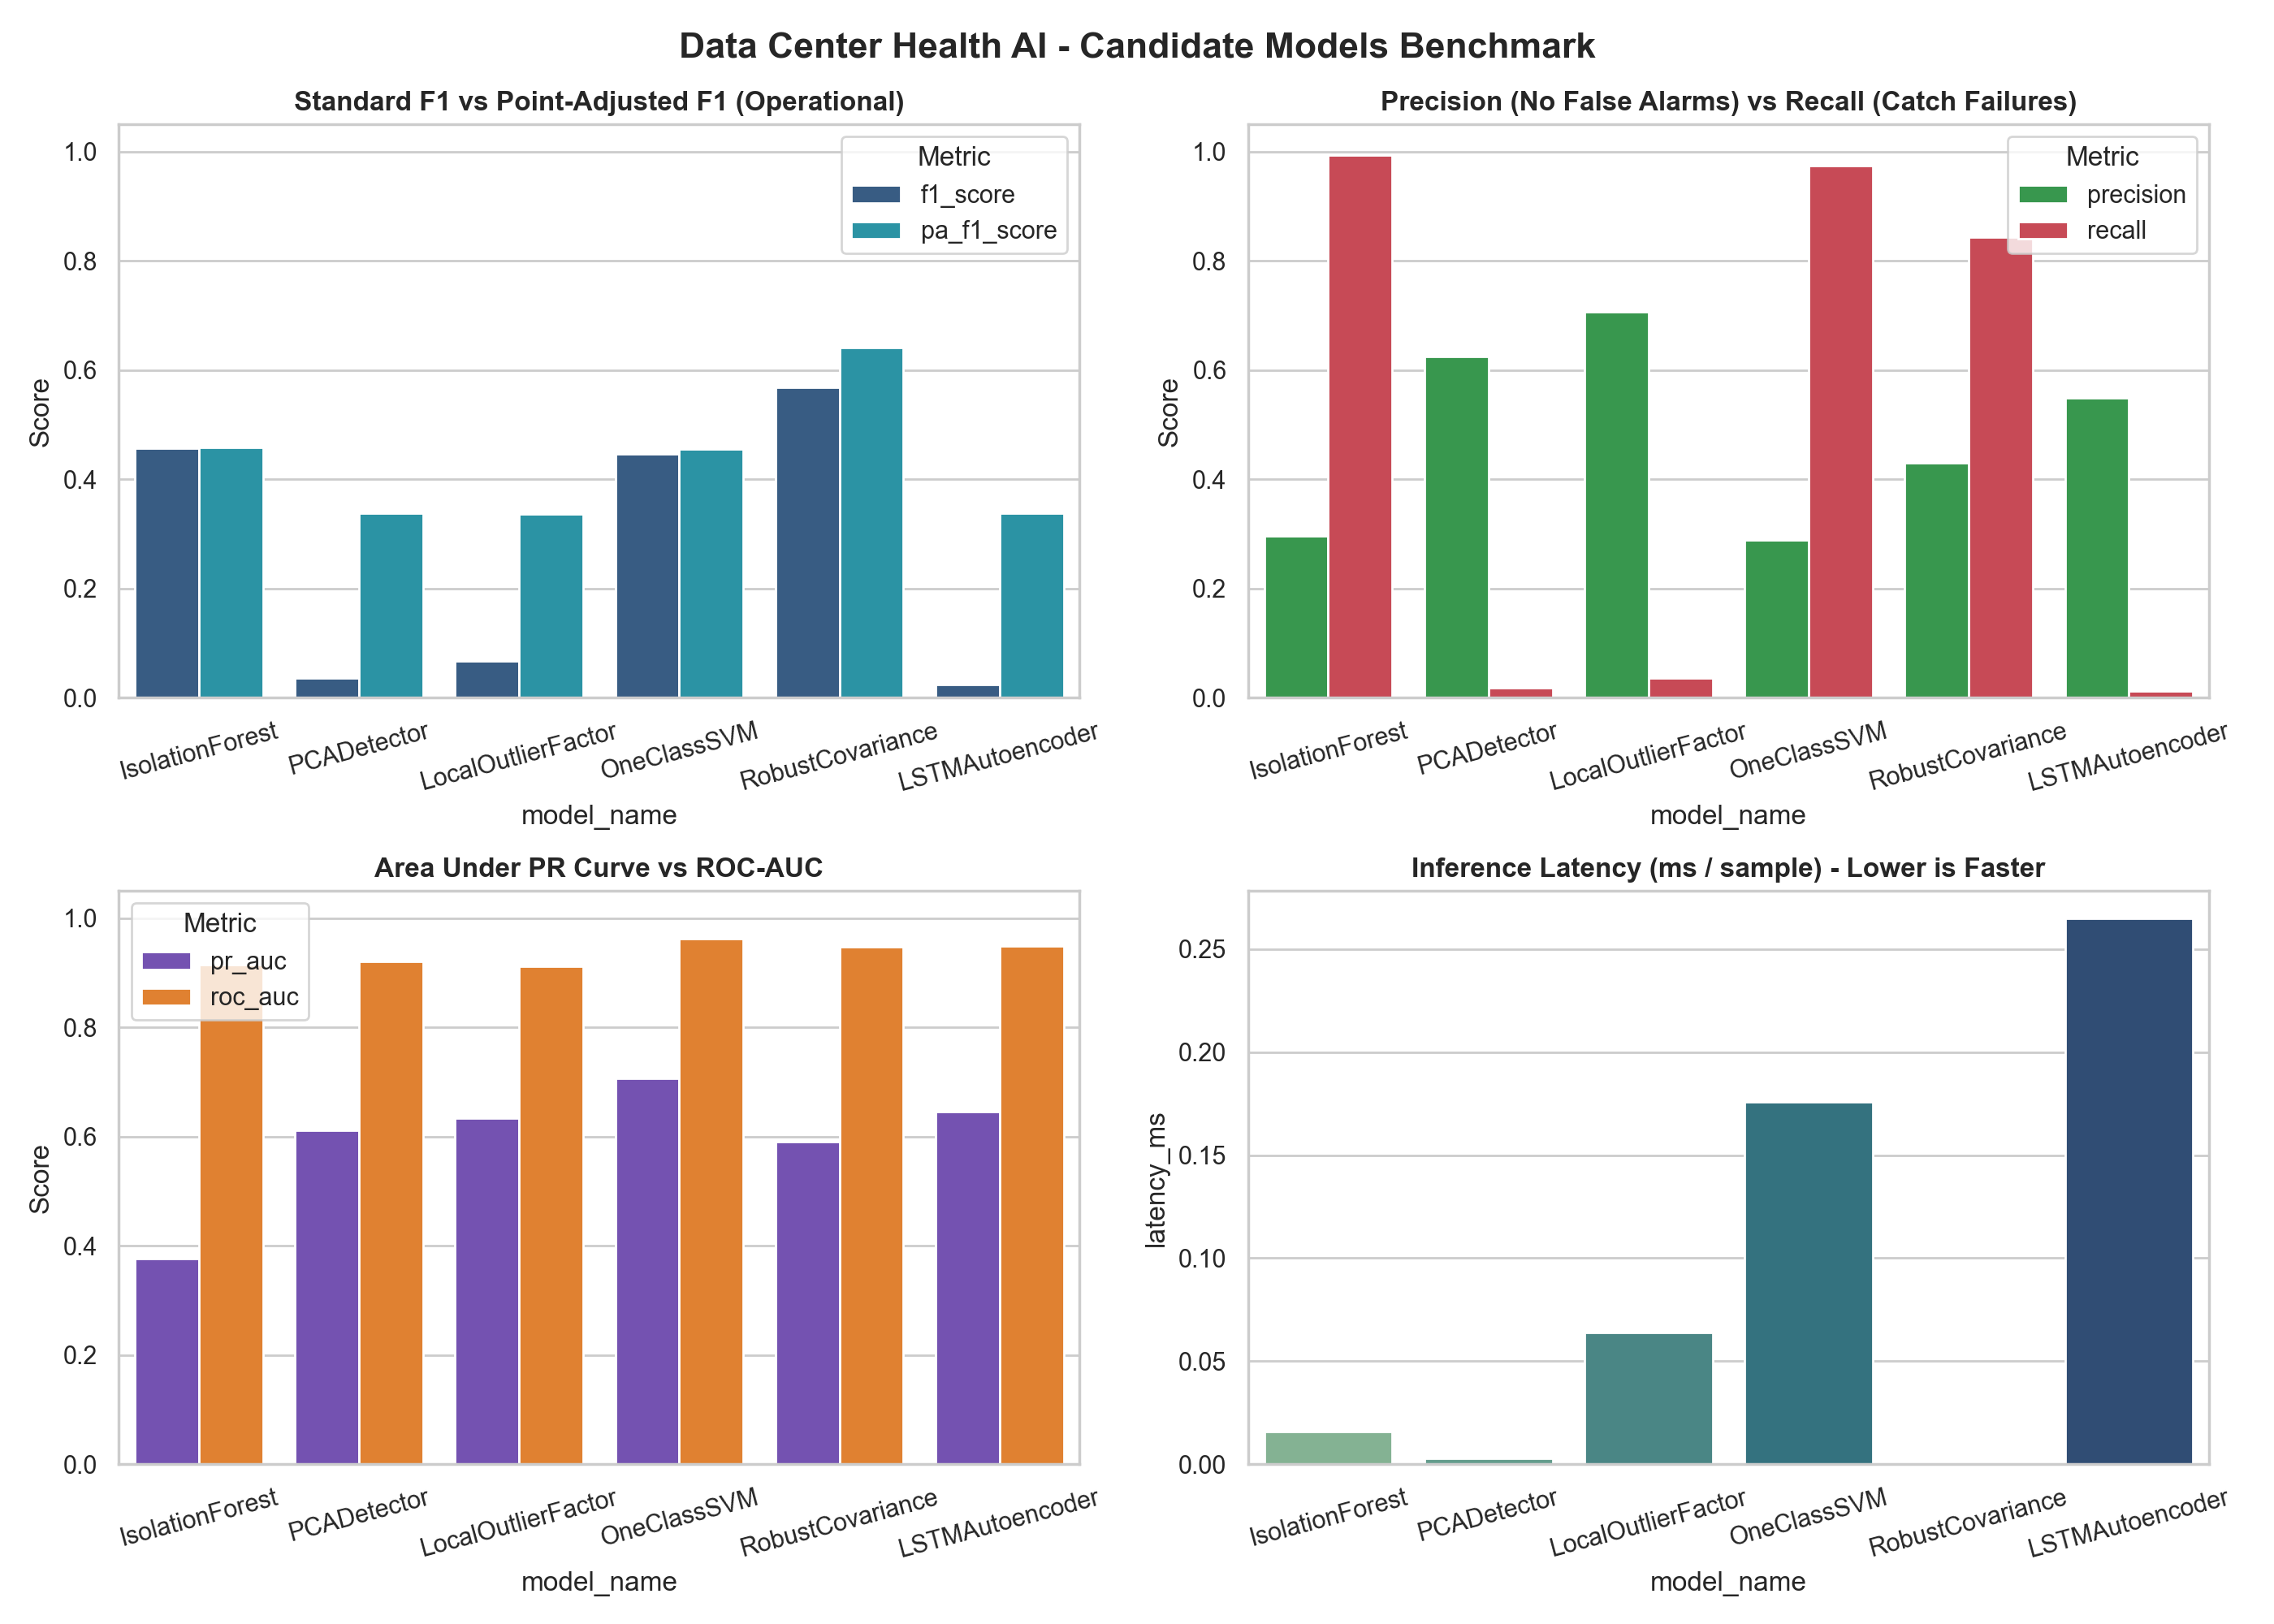

In [2]:
from IPython.display import Image
chart_path = project_root / 'artifacts' / 'reports' / 'model_benchmark_comparison.png'
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print("Benchmark chart not found.")

## 3. Champion Model Verification & Inference Test

In [3]:
from src.ml.model_registry import inference_engine

# 1. Score real ground-truth nominal telemetry
df_train = pd.read_csv(project_root / 'data' / 'processed' / 'machine-1-1_train_scaled.csv')
nom_slice = df_train.iloc[:60].values
nom_raw = inference_engine.scaler.inverse_transform(nom_slice)
nominal_score = inference_engine.score_telemetry(nom_raw)

# 2. Score real ground-truth anomaly telemetry segment
df_test = pd.read_csv(project_root / 'data' / 'processed' / 'machine-1-1_test_scaled.csv')
df_labels = pd.read_csv(project_root / 'data' / 'processed' / 'machine-1-1_test_labels.csv')
anom_idx = int(np.where(df_labels.iloc[:, 0].values == 1)[0][0])
anom_slice = df_test.iloc[anom_idx:anom_idx+60].values
anom_raw = inference_engine.scaler.inverse_transform(anom_slice)
anomaly_score = inference_engine.score_telemetry(anom_raw)

print("Nominal Telemetry Scoring:", nominal_score)
print("Anomaly Telemetry Scoring:", anomaly_score)

assert nominal_score['severity'] == 'NORMAL', "Nominal telemetry must be normal!"
assert anomaly_score['risk_score'] >= 50.0, "Anomaly telemetry must trigger elevated risk!"
print("✅ Champion Model Production Scoring Verified Successfully!")

2026-09-07 21:10:46 [INFO] [DataCenterHealthAI:load_champion_artifacts:51] - [InferenceEngine] Loaded champion model: RobustCovariance


2026-09-07 21:10:46 [INFO] [DataCenterHealthAI:load_champion_artifacts:57] - [InferenceEngine] Loaded feature scaler for machine-1-1


Nominal Telemetry Scoring: {'risk_score': 4.8, 'is_anomaly': False, 'severity': 'NORMAL', 'anomalous_sensors': [], 'latency_ms': 2.25, 'model_name': 'RobustCovariance', 'timestamp': 1788795646.7134058}
Anomaly Telemetry Scoring: {'risk_score': 100.0, 'is_anomaly': True, 'severity': 'CRITICAL', 'anomalous_sensors': ['CPU_Utilization_Pct', 'Net_Drop_In_Sec'], 'latency_ms': 2.0, 'model_name': 'RobustCovariance', 'timestamp': 1788795647.2632482}
✅ Champion Model Production Scoring Verified Successfully!
